Run `python run_pipeline.py` from the project root (or execute each model
notebook once, in any order) so every `metrics_*.csv` lands in `../results/`,
then run this notebook. It reads those files and writes
`comparison_summary.csv` and `best_model_by_window.csv` back to `../results/`.

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [1]:
MODEL_FILES = {
    "VECM": "../results/metrics_var_vecm.csv",
    "ARIMA": "../results/metrics_arima.csv",
    "LSTM": "../results/metrics_lstm.csv",
    "TDNN": "../results/metrics_tdnn.csv",
    "FFNN": "../results/metrics_ffnn.csv",
    "Hybrid_Residual": "../results/metrics_hybrid_residual.csv",
    "Hybrid_Neural": "../results/metrics_hybrid_neural.csv",
    "Ensemble_Simple": "../results/metrics_hybrid_ensemble_simple.csv",
    "Ensemble_Weighted": "../results/metrics_hybrid_ensemble_weighted.csv",
    "Ensemble_Stacked": "../results/metrics_hybrid_ensemble_stacked.csv",
}
WINDOW_COLS = ["W1", "W2", "W3", "W4", "W5"]


In [5]:
import os

def load_metrics(model: str, path: str) -> pd.DataFrame:
    """Load one model's standardized long-format export: window, target, RMSE, MAE."""
    df = pd.read_csv(path)
    df.insert(0, "model", model)
    return df


available = {}
for model, path in MODEL_FILES.items():
    if os.path.exists(path):
        available[model] = load_metrics(model, path)
    else:
        print(f"[skip] {path} not found — excluding {model} from the comparison")

long_df = pd.concat(available.values(), ignore_index=True)
long_df


,model,window,target,RMSE,MAE
0,VECM,W1,CPI,4.605201,3.972368
1,VECM,W1,EXR,4.663703,4.266680
2,VECM,W2,CPI,2.210647,1.900296
3,VECM,W2,EXR,5.841530,5.379869
4,VECM,W3,CPI,6.516029,5.157529
...,...,...,...,...,...
95,Ensemble_Stacked,W3,EXR,8.610959,8.016288
96,Ensemble_Stacked,W4,CPI,3.042829,3.037297
97,Ensemble_Stacked,W4,EXR,7.365443,6.954511
98,Ensemble_Stacked,W5,CPI,8.252797,5.568296


In [6]:
# Rows: model x target x metric. Columns: W1..W5.
comparison = (
    long_df
    .melt(id_vars=["model", "window", "target"], value_vars=["RMSE", "MAE"], var_name="metric")
    .pivot_table(index=["model", "target", "metric"], columns="window", values="value")
    .reindex(columns=WINDOW_COLS)
    .reindex(MODEL_FILES.keys(), level="model")
)
comparison.round(4)

window                                W1       W2       W3       W4        W5
model             target metric                                              
VECM              CPI    MAE      3.9724   1.9003   5.1575  22.1381   38.1843
                         RMSE     4.6052   2.2106   6.5160  23.2167   41.7019
                  EXR    MAE      4.2667   5.3799   7.8951  12.0885  106.2636
                         RMSE     4.6637   5.8415   9.9994  14.6161  124.5505
ARIMA             CPI    MAE      7.3312   3.5954  11.6650   5.0124   13.9772
                         RMSE     8.6187   4.2849  15.2640   5.1161   17.2782
                  EXR    MAE      3.1369   8.2943   0.5837   2.3589   35.7643
                         RMSE     3.4391   9.0520   0.6432   2.4349   39.3133
LSTM              CPI    MAE     10.2457   1.6649  10.5894   2.0346    8.0564
                         RMSE    10.8902   2.3240  13.6506   2.3010   11.7554
                  EXR    MAE      2.8295   5.6079   1.8837   6.7517   15.7182
                         RMSE     3.0760   5.8992   2.3776   6.8582   21.3244
TDNN              CPI    MAE      7.8650   1.9748   4.4408   3.1020   48.1173
                         RMSE     8.9941   2.3240   7.1996   3.6890   55.0373
                  EXR    MAE      2.5837   8.9111  11.1150   4.0130   40.0799
                         RMSE     2.7521  10.0683  13.8351   5.0184   56.2680
FFNN              CPI    MAE      5.1803   6.8634  14.8074   2.9651   47.5398
                         RMSE     5.6309   7.1902  16.8730   3.0421   48.3946
                  EXR    MAE      5.0854   8.1720   8.8783   7.5380    9.6391
                         RMSE     5.1534   8.1970   9.4218   8.0445   10.1853
Hybrid_Residual   CPI    MAE      7.1116   3.3371  11.3228   5.4401   14.0433
                         RMSE     8.4104   3.9887  14.9929   5.5580   17.3708
                  EXR    MAE      3.2707   8.1675   0.5779   1.9353   35.9185
                         RMSE     3.6254   8.8953   0.7321   1.9961   39.5351
Hybrid_Neural     CPI    MAE      8.9873   2.2682  15.1602   1.7898  105.0917
                         RMSE    11.1490   3.0836  19.4094   2.3170  115.7290
                  EXR    MAE      1.5547   6.0509  10.7474   8.5722   98.0421
                         RMSE     1.7565   7.4815  11.0827   9.3274  110.9694
Ensemble_Simple   CPI    MAE      8.7817   1.9755  11.6902   3.0373   13.2834
                         RMSE     9.1453   2.5665  13.8311   3.0428   17.4027
                  EXR    MAE      4.0100   8.6620   8.0163   6.9545   23.4007
                         RMSE     4.0421   8.6751   8.6110   7.3654   27.1185
Ensemble_Weighted CPI    MAE      7.8368   1.5375  10.0820   1.1404    9.6449
                         RMSE     8.1979   1.8690  12.2054   1.2762   11.0893
                  EXR    MAE      3.7403   8.1183   1.6074   3.4060   11.7507
                         RMSE     3.7780   8.1352   1.7922   3.7093   13.0610
Ensemble_Stacked  CPI    MAE      8.7817   1.9755  11.6902   3.0373    5.5683
                         RMSE     9.1453   2.5665  13.8311   3.0428    8.2528
                  EXR    MAE      4.0100   8.6620   8.0163   6.9545    6.4310
                         RMSE     4.0421   8.6751   8.6110   7.3654    7.6194

In [7]:
# Best-performing model per window/target, ranked by RMSE.
best_by_window = (
    long_df.loc[long_df.groupby(["window", "target"])["RMSE"].idxmin(), ["window", "target", "model", "RMSE"]]
    .set_index(["window", "target"])
    .sort_index()
)
best_by_window

model      RMSE
window target                             
W1     CPI                  VECM  4.605201
       EXR         Hybrid_Neural  1.756537
W2     CPI     Ensemble_Weighted  1.868965
       EXR                  VECM  5.841530
W3     CPI                  VECM  6.516029
       EXR                 ARIMA  0.643180
W4     CPI     Ensemble_Weighted  1.276187
       EXR       Hybrid_Residual  1.996118
W5     CPI      Ensemble_Stacked  8.252797
       EXR      Ensemble_Stacked  7.619369

In [9]:
# Persist the cross-model comparison so it survives outside this notebook.
comparison.round(4).to_csv("../results/comparison_summary.csv")
best_by_window.to_csv("../results/best_model_by_window.csv")


In [10]:
PRED_FILES = {
    "VECM": ("../results/predictions_var_vecm.csv", "predicted"),
    "ARIMA": ("../results/predictions_arima.csv", "predicted"),
    "LSTM": ("../results/predictions_lstm.csv", "predicted"),
    "TDNN": ("../results/predictions_tdnn.csv", "predicted"),
    "FFNN": ("../results/predictions_ffnn.csv", "predicted"),
    "Hybrid_Residual": ("../results/predictions_hybrid_residual.csv", "predicted"),
    "Hybrid_Neural": ("../results/predictions_hybrid_neural.csv", "predicted"),
    "Ensemble_Simple": ("../results/predictions_hybrid_ensemble.csv", "simple"),
    "Ensemble_Weighted": ("../results/predictions_hybrid_ensemble.csv", "weighted"),
    "Ensemble_Stacked": ("../results/predictions_hybrid_ensemble.csv", "stacked"),
}


def load_predictions(pred_files: dict) -> pd.DataFrame:
    """Load every model's raw-scale test predictions into one long frame: model, window, target, date, actual, predicted."""
    cache, frames = {}, []
    for model, (path, value_col) in pred_files.items():
        if not os.path.exists(path):
            print(f"[skip] {path} not found — excluding {model}")
            continue
        if path not in cache:
            cache[path] = pd.read_csv(path, parse_dates=["date"])
        sub = cache[path][["window", "target", "date", "actual", value_col]].rename(columns={value_col: "predicted"})
        sub.insert(0, "model", model)
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)


long_pred = load_predictions(PRED_FILES)
long_pred = long_pred.sort_values(["model", "window", "target", "date"])

In [12]:
def compute_extended_metrics(group: pd.DataFrame) -> pd.Series:
    """
    RMSE, MAE, MAPE, out-of-sample MASE, and directional accuracy for one model/window/target.

    MASE scales MAE by the mean absolute step-to-step change in this window's own test
    actuals (out-of-sample naive) — not Hyndman's in-sample training-residual scale,
    since exports don't retain per-window training residuals.
    """
    g = group.sort_values("date")
    actual, predicted = g["actual"].values, g["predicted"].values

    rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
    mae = float(mean_absolute_error(actual, predicted))
    mape = float(np.mean(np.abs((actual - predicted) / actual)) * 100)

    naive_err = np.abs(np.diff(actual))
    mase = mae / naive_err.mean() if len(naive_err) and naive_err.mean() > 0 else np.nan

    if len(actual) > 1:
        actual_dir = np.sign(np.diff(actual))
        pred_dir = np.sign(predicted[1:] - actual[:-1])
        dir_acc = float(np.mean(actual_dir == pred_dir) * 100)
    else:
        dir_acc = np.nan

    return pd.Series({"RMSE": rmse, "MAE": mae, "MAPE": mape, "MASE": mase, "Dir%": dir_acc})


extended_metrics = (
    long_pred.groupby(["model", "window", "target"])
    .apply(compute_extended_metrics)
    .reset_index()
)

In [15]:
def ranked_table(extended_metrics: pd.DataFrame, window: str, target: str) -> pd.DataFrame:
    """Rank models by RMSE for one window/target."""
    sub = extended_metrics[(extended_metrics["window"] == window) & (extended_metrics["target"] == target)]
    sub = sub.sort_values("RMSE").reset_index(drop=True)
    sub.insert(0, "Rank", sub.index + 1)
    return sub[["Rank", "model", "RMSE", "MAE", "MAPE", "MASE", "Dir%"]].round(4)


WINDOWS = ["W1", "W2", "W3", "W4", "W5"]
TARGETS = ["CPI", "EXR"]

for window in WINDOWS:
    for target in TARGETS:
        print(f"    {target} Forecasting ({window})    ")
        display(ranked_table(extended_metrics, window, target))

    CPI Forecasting (W1)    


,Rank,model,RMSE,MAE,MAPE,MASE,Dir%
0,1,VECM,4.6052,3.9724,4.6182,2.2200,12.5000
1,2,FFNN,5.6309,5.1803,5.9246,2.8381,0.0000
2,3,Ensemble_Weighted,8.1979,7.8368,9.0005,4.2934,0.0000
3,4,Hybrid_Residual,8.4104,7.1116,8.2376,3.9744,12.5000
4,5,ARIMA,8.6187,7.3312,8.4982,4.0971,12.5000
5,6,TDNN,8.9941,7.8650,9.4281,5.0761,0.0000
6,7,Ensemble_Stacked,9.1453,8.7817,10.0917,4.8111,0.0000
7,8,Ensemble_Simple,9.1453,8.7817,10.0917,4.8111,0.0000
8,9,LSTM,10.8902,10.2457,11.9463,5.9797,0.0000
9,10,Hybrid_Neural,11.1490,8.9873,10.6219,5.8004,8.3333


    EXR Forecasting (W1)    


,Rank,model,RMSE,MAE,MAPE,MASE,Dir%
0,1,Hybrid_Neural,1.7565,1.5547,1.4048,2.2792,33.3333
1,2,TDNN,2.7521,2.5837,2.3392,3.7878,33.3333
2,3,LSTM,3.0760,2.8295,2.6043,3.6564,28.5714
3,4,ARIMA,3.4391,3.1369,2.8902,4.4040,37.5000
4,5,Hybrid_Residual,3.6254,3.2707,3.0155,4.5919,37.5000
5,6,Ensemble_Weighted,3.7780,3.7403,3.4626,13.0362,20.0000
6,7,Ensemble_Stacked,4.0421,4.0100,3.7120,13.9761,20.0000
7,8,Ensemble_Simple,4.0421,4.0100,3.7120,13.9761,20.0000
8,9,VECM,4.6637,4.2667,3.9301,5.9901,12.5000
9,10,FFNN,5.1534,5.0854,4.7079,17.7241,20.0000


    CPI Forecasting (W2)    


...

,Rank,model,RMSE,MAE,MAPE,MASE,Dir%
0,1,Hybrid_Residual,1.9961,1.9353,0.6426,2.5365,100.0
1,2,ARIMA,2.4349,2.3589,0.7829,3.0917,100.0
2,3,Ensemble_Weighted,3.7093,3.4060,1.1270,5.1606,0.0
3,4,TDNN,5.0184,4.0130,1.3356,3.9884,25.0
4,5,LSTM,6.8582,6.7517,2.2383,8.0449,0.0
5,6,Ensemble_Stacked,7.3654,6.9545,2.3017,10.5371,0.0
6,7,Ensemble_Simple,7.3654,6.9545,2.3017,10.5371,0.0
7,8,FFNN,8.0445,7.5380,2.4946,11.4212,0.0
8,9,Hybrid_Neural,9.3274,8.5722,2.8508,8.5196,12.5
9,10,VECM,14.6161,12.0885,4.0040,15.8434,0.0


    CPI Forecasting (W5)    


,Rank,model,RMSE,MAE,MAPE,MASE,Dir%
0,1,Ensemble_Stacked,8.2528,5.5683,1.8507,1.8440,53.8462
1,2,Ensemble_Weighted,11.0893,9.6449,3.1818,3.1940,50.0000
2,3,LSTM,11.7554,8.0564,2.6902,2.9295,61.5385
3,4,ARIMA,17.2782,13.9772,4.7300,4.5911,55.0000
4,5,Hybrid_Residual,17.3708,14.0433,4.7501,4.6128,55.0000
5,6,Ensemble_Simple,17.4027,13.2834,4.2744,4.3989,57.6923
6,7,VECM,41.7019,38.1843,12.7360,12.5424,32.5000
7,8,FFNN,48.3946,47.5398,15.6588,15.7433,53.8462
8,9,TDNN,55.0373,48.1173,16.4176,11.3611,40.7407
9,10,Hybrid_Neural,115.7290,105.0917,35.7031,24.8134,33.3333


    EXR Forecasting (W5)    


,Rank,model,RMSE,MAE,MAPE,MASE,Dir%
0,1,Ensemble_Stacked,7.6194,6.4310,2.0920,2.5274,34.6154
1,2,FFNN,10.1853,9.6391,3.1586,3.7882,57.6923
2,3,Ensemble_Weighted,13.0610,11.7507,3.8584,4.6180,53.8462
3,4,LSTM,21.3244,15.7182,4.7816,4.0562,56.4103
4,5,Ensemble_Simple,27.1185,23.4007,7.6362,9.1965,42.3077
5,6,ARIMA,39.3133,35.7643,11.6394,9.4267,55.0000
6,7,Hybrid_Residual,39.5351,35.9185,11.6930,9.4674,55.0000
7,8,TDNN,56.2680,40.0799,12.1373,6.8213,40.7407
8,9,Hybrid_Neural,110.9694,98.0421,30.6532,16.6861,37.0370
9,10,VECM,124.5505,106.2636,33.9111,28.0089,55.0000


In [20]:
BEST_MODELS = {
    ("W1", "CPI"): "VECM",
    ("W1", "EXR"): "Hybrid_Neural",
    ("W2", "CPI"): "Ensemble_Weighted",
    ("W2", "EXR"): "VECM",
    ("W3", "CPI"): "VECM",
    ("W3", "EXR"): "ARIMA",
    ("W4", "CPI"): "Ensemble_Weighted",
    ("W4", "EXR"): "Hybrid_Residual",
    ("W5", "CPI"): "Ensemble_Stacked",
    ("W5", "EXR"): "Ensemble_Stacked",
}

In [21]:
def actual_vs_best_forecast(long_pred: pd.DataFrame, window: str, target: str, model: str) -> pd.DataFrame:
    """Actual value alongside the best-performing model's forecast, one row per test date."""
    sub = long_pred[(long_pred["window"] == window) & (long_pred["target"] == target) & (long_pred["model"] == model)]
    return sub.set_index("date")[["actual", "predicted"]].rename(columns={"predicted": model}).round(2)


for (window, target), model in BEST_MODELS.items():
    print(f"=== {target}: Actual vs {model} ({window}) ===")
    display(actual_vs_best_forecast(long_pred, window, target, model))

=== CPI: Actual vs VECM (W1) ===


,actual,VECM
date,,
2007-09-01,75.87,75.36
2007-10-01,78.19,76.25
2007-11-01,80.28,77.97
2007-12-01,81.06,78.61
2008-01-01,83.63,80.91
2008-02-01,86.03,80.32
2008-03-01,87.36,81.34
2008-04-01,88.99,82.02
2008-05-01,90.18,83.07


=== EXR: Actual vs Hybrid_Neural (W1) ===


,actual,Hybrid_Neural
date,,
2007-05-01,110.85,109.83
2007-06-01,110.97,109.88
2007-07-01,111.66,109.81
2007-08-01,112.11,109.82
2007-09-01,113.34,110.03
2007-10-01,113.06,110.25
2007-11-01,110.51,110.32
2007-12-01,109.08,109.89
2008-01-01,108.25,109.77


=== CPI: Actual vs Ensemble_Weighted (W2) ===


...

,actual,Hybrid_Residual
date,,
2025-05-01,299.25,297.42
2025-06-01,299.71,301.44
2025-07-01,301.08,303.61
2025-08-01,301.31,302.38
2025-09-01,302.09,304.55
2025-10-01,303.06,305.07


=== CPI: Actual vs Ensemble_Stacked (W5) ===


,actual,Ensemble_Stacked
date,,
2023-08-01,305.42,306.20
2023-09-01,307.84,305.75
2023-10-01,308.00,306.88
2023-11-01,311.63,306.25
2023-12-01,315.86,308.49
2024-01-01,325.24,308.63
2024-02-01,324.48,309.82
2024-03-01,317.68,311.61
2024-04-01,314.95,313.59


=== EXR: Actual vs Ensemble_Stacked (W5) ===


,actual,Ensemble_Stacked
date,,
2023-08-01,321.58,322.47
2023-09-01,322.77,314.84
2023-10-01,324.73,313.60
2023-11-01,328.25,312.84
2023-12-01,326.74,313.57
2024-01-01,321.17,314.12
2024-02-01,312.58,317.82
2024-03-01,305.67,317.78
2024-04-01,299.42,313.77


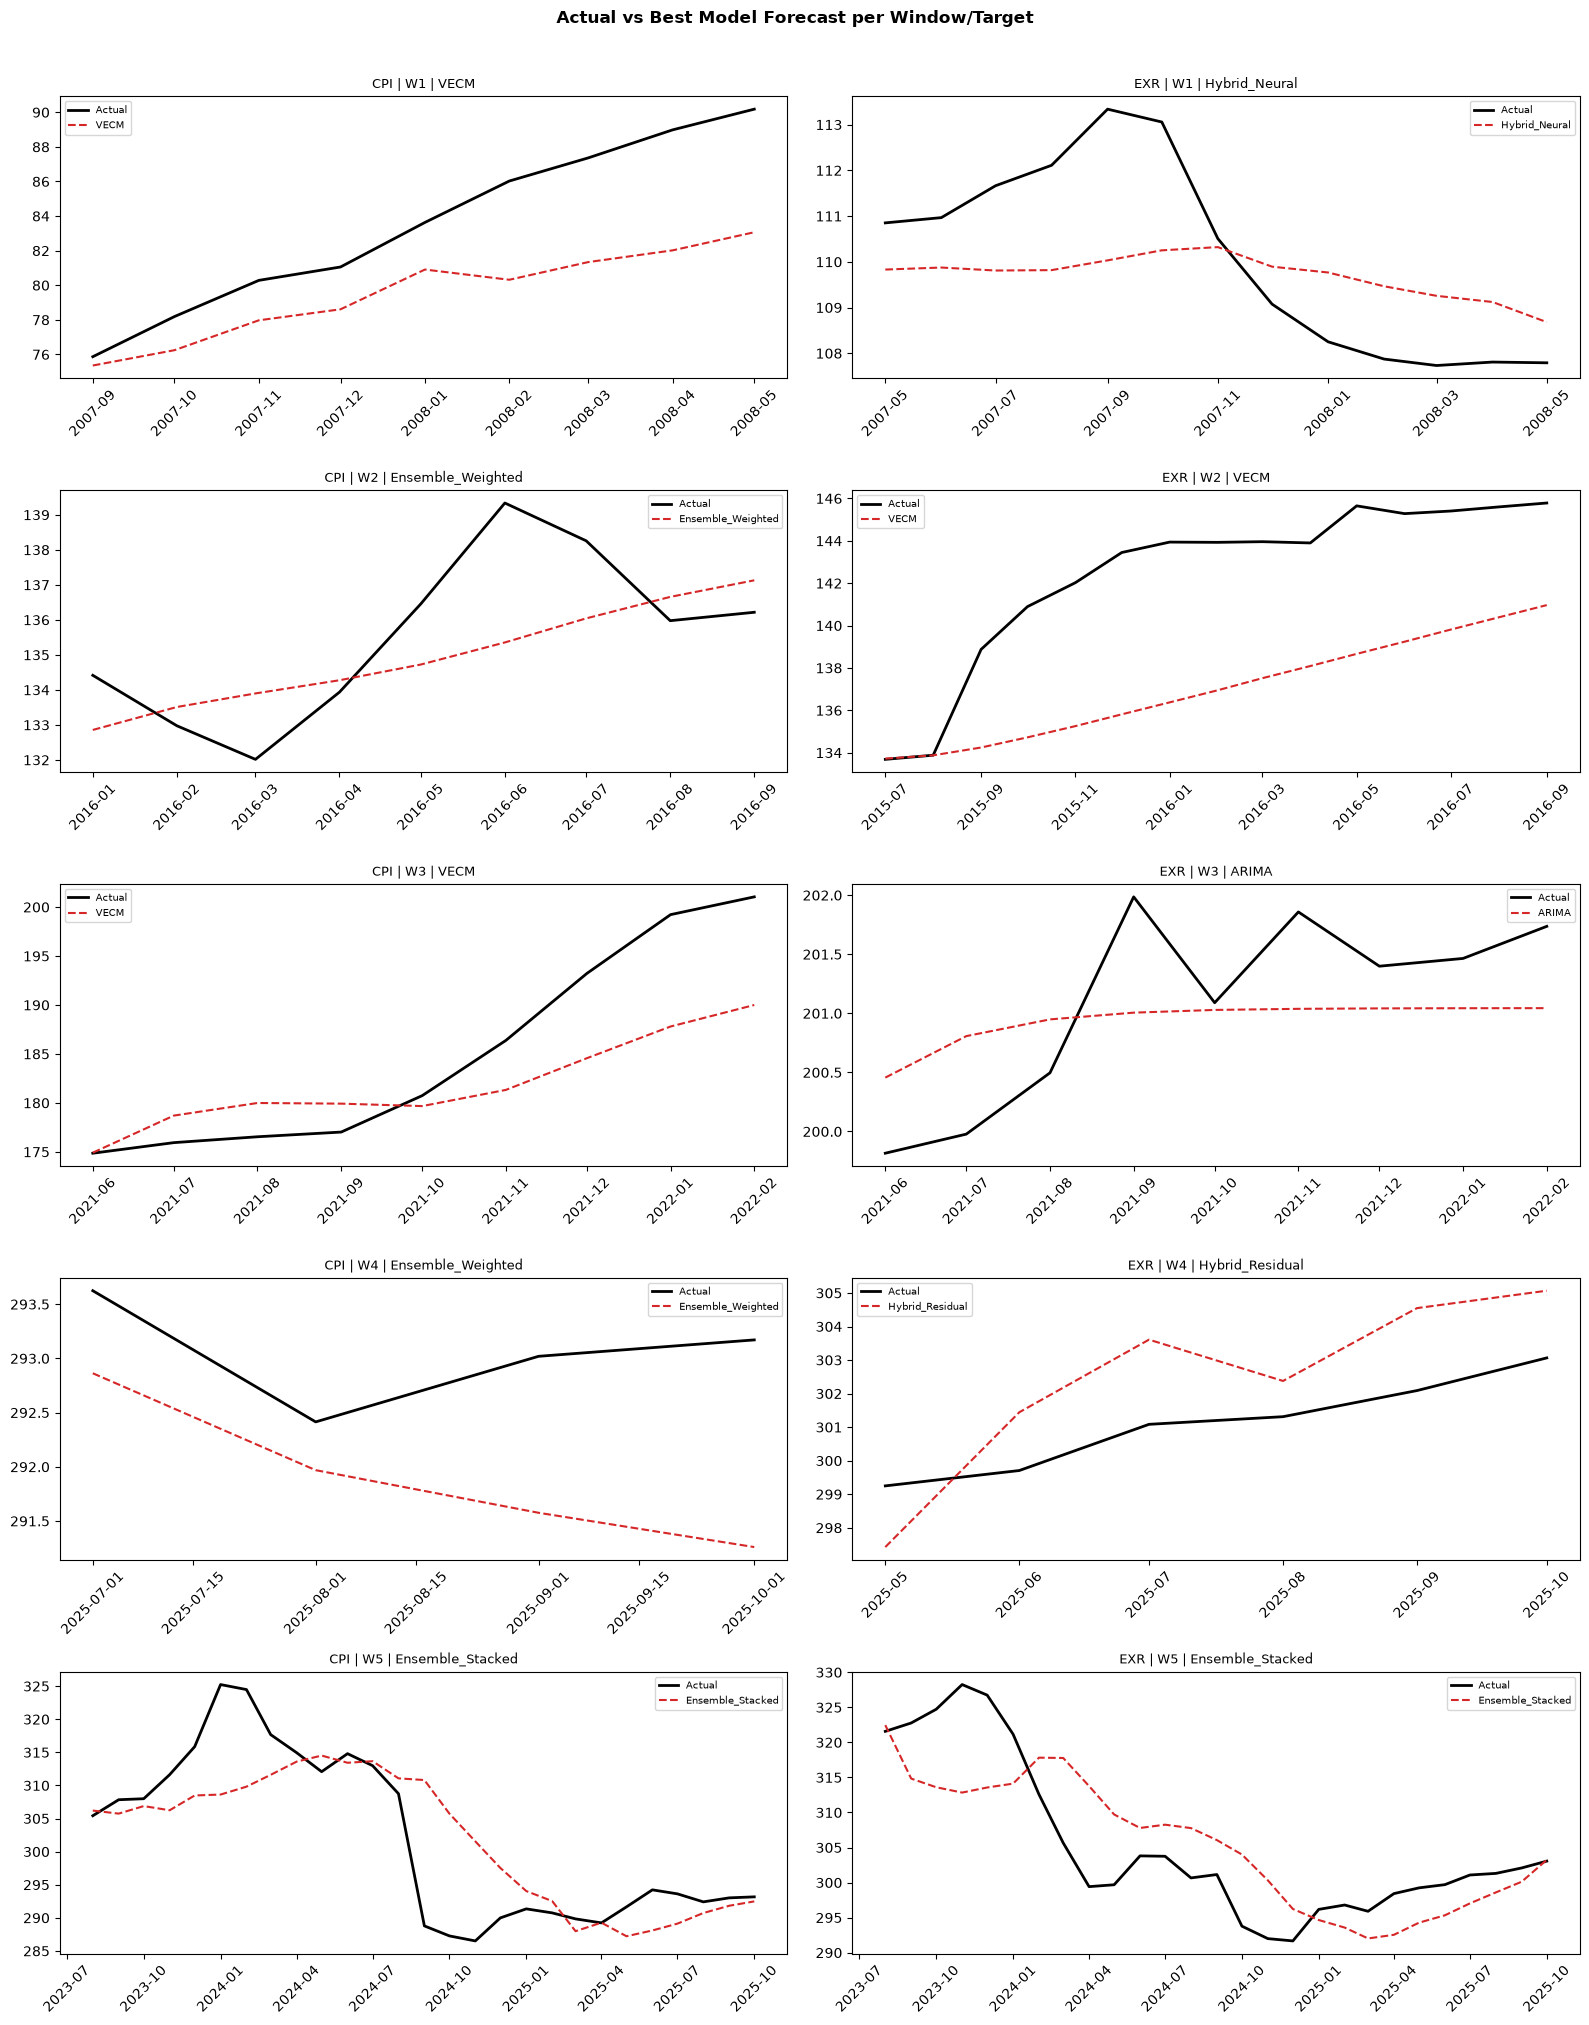

In [23]:
fig, axes = plt.subplots(5, 2, figsize=(8 * 2, 4 * 5), sharey=False)

for i, target in enumerate(TARGETS):
    for j, window in enumerate(WINDOWS):
        ax = axes[j, i]  # 5 rows (windows), 2 cols (targets) -- 2 per row
        model = BEST_MODELS[(window, target)]
        sub = long_pred[
            (long_pred["window"] == window) & (long_pred["target"] == target) & (long_pred["model"] == model)
        ].sort_values("date")

        ax.plot(sub["date"], sub["actual"], color="black", lw=2, label="Actual")
        ax.plot(sub["date"], sub["predicted"], color="tab:red", lw=1.5, ls="--", label=model)
        ax.set_title(f"{target} | {window} | {model}", fontsize=9)
        ax.tick_params(axis="x", labelrotation=45)
        ax.legend(fontsize=7)

plt.suptitle("Actual vs Best Model Forecast per Window/Target", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/forecast_best_models.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
extended_metrics.round(4).to_csv("../results/comparison_summary_extended.csv", index=False)